In [ ]:
!pip install -q kagglehub

import kagglehub


path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

100%|██████████| 93.9k/93.9k [00:00<00:00, 800kB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9
['StudentPerformanceFactors.csv']


In [ ]:
import pandas as pd

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
import pandas as pd
import numpy as np


print("Data types:\n")
print(df.dtypes)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Object columns:", object_cols)

Data types:

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Numeric columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Object columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',

In [ ]:
for c in object_cols:
    print(c, "->", df[c].unique())

Parental_Involvement -> ['Low' 'Medium' 'High']
Access_to_Resources -> ['High' 'Medium' 'Low']
Extracurricular_Activities -> ['No' 'Yes']
Motivation_Level -> ['Low' 'Medium' 'High']
Internet_Access -> ['Yes' 'No']
Family_Income -> ['Low' 'Medium' 'High']
Teacher_Quality -> ['Medium' 'High' 'Low' nan]
School_Type -> ['Public' 'Private']
Peer_Influence -> ['Positive' 'Negative' 'Neutral']
Learning_Disabilities -> ['No' 'Yes']
Parental_Education_Level -> ['High School' 'College' 'Postgraduate' nan]
Distance_from_Home -> ['Near' 'Moderate' 'Far' nan]
Gender -> ['Male' 'Female']


In [ ]:
df_encoded = df.copy()


ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}

for c in object_cols:
    uniques = set(df_encoded[c].dropna().unique())
    if uniques.issubset(set(ordinal_map.keys())):

        df_encoded[c] = df_encoded[c].map(ordinal_map)
    else:

        df_encoded = pd.get_dummies(df_encoded, columns=[c], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (6607, 23)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Internet_Access_Yes,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,0,2,7,73,0,0,0,1.0,...,True,True,False,True,False,True,False,False,True,True
1,19,64,0,1,8,59,0,2,1,1.0,...,True,True,False,False,False,False,False,True,False,False
2,24,98,1,1,7,91,1,2,1,1.0,...,True,True,True,False,False,False,True,False,True,True
3,29,89,0,1,8,98,1,1,1,1.0,...,True,True,False,False,False,True,False,True,False,True
4,19,92,1,1,6,65,1,3,1,2.0,...,True,True,True,False,False,False,False,False,True,False


In [ ]:
null_counts = df.isnull().sum()
print("Columns with nulls:\n")
print(null_counts[null_counts > 0])

Columns with nulls:

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [ ]:
df_clean = df_encoded.copy()

for c in df_clean.columns:
    if df_clean[c].isnull().sum() > 0:
        if df_clean[c].dtype in [np.float64, np.int64]:

            df_clean[c].fillna(df_clean[c].median(), inplace=True)
        else:

            df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)

print("Remaining nulls:", df_clean.isnull().sum().sum())
df_clean.head()

Remaining nulls: 0


/tmp/ipykernel_1282/2449300503.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[c].fillna(df_clean[c].median(), inplace=True)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Internet_Access_Yes,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,0,2,7,73,0,0,0,1.0,...,True,True,False,True,False,True,False,False,True,True
1,19,64,0,1,8,59,0,2,1,1.0,...,True,True,False,False,False,False,False,True,False,False
2,24,98,1,1,7,91,1,2,1,1.0,...,True,True,True,False,False,False,True,False,True,True
3,29,89,0,1,8,98,1,1,1,1.0,...,True,True,False,False,False,True,False,True,False,True
4,19,92,1,1,6,65,1,3,1,2.0,...,True,True,True,False,False,False,False,False,True,False


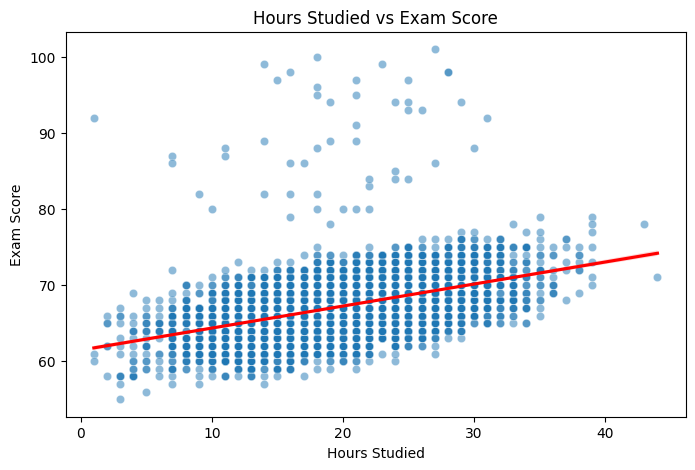

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', alpha=0.5)
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score', scatter=False, color='red')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

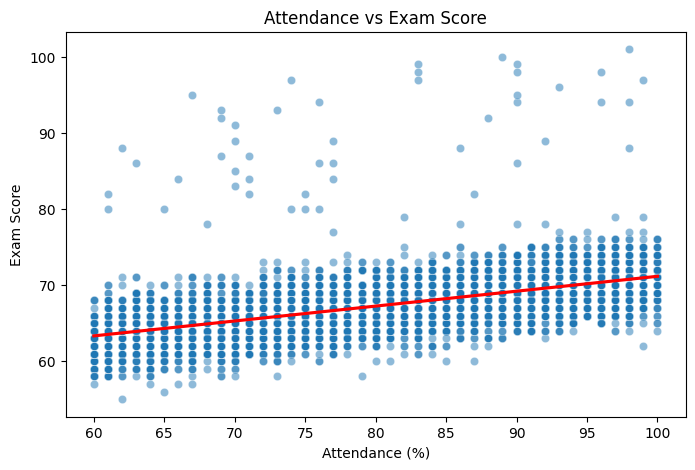

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Attendance', y='Exam_Score', alpha=0.5)
sns.regplot(data=df, x='Attendance', y='Exam_Score', scatter=False, color='red')
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.show()

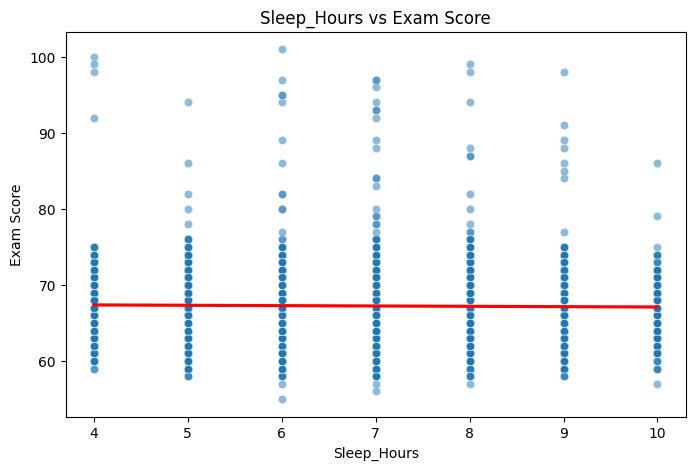

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sleep_Hours', y='Exam_Score', alpha=0.5)
sns.regplot(data=df, x='Sleep_Hours', y='Exam_Score', scatter=False, color='red')
plt.title('Sleep_Hours vs Exam Score')
plt.xlabel('Sleep_Hours')
plt.ylabel('Exam Score')
plt.show()

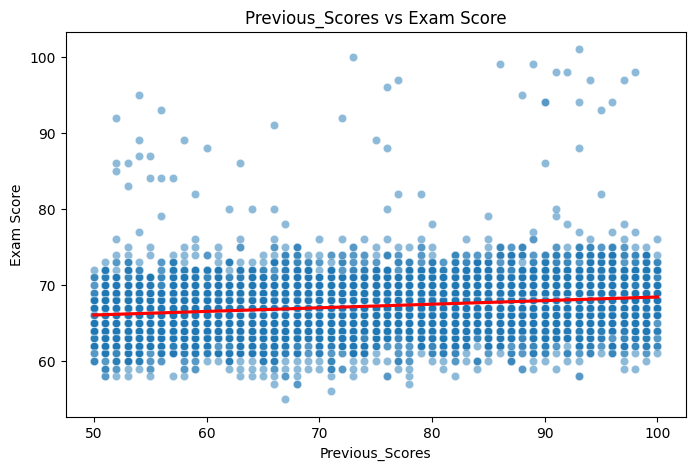

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Previous_Scores', y='Exam_Score', alpha=0.5)
sns.regplot(data=df, x='Previous_Scores', y='Exam_Score', scatter=False, color='red')
plt.title('Previous_Scores vs Exam Score')
plt.xlabel('Previous_Scores')
plt.ylabel('Exam Score')
plt.show()

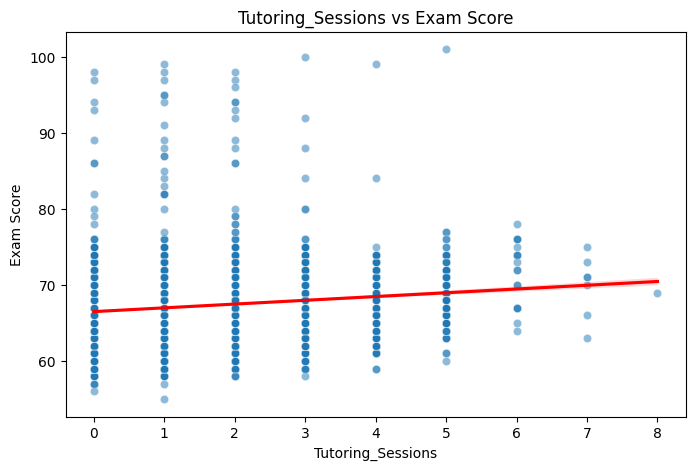

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Tutoring_Sessions', y='Exam_Score', alpha=0.5)
sns.regplot(data=df, x='Tutoring_Sessions', y='Exam_Score', scatter=False, color='red')
plt.title('Tutoring_Sessions vs Exam Score')
plt.xlabel('Tutoring_Sessions')
plt.ylabel('Exam Score')
plt.show()

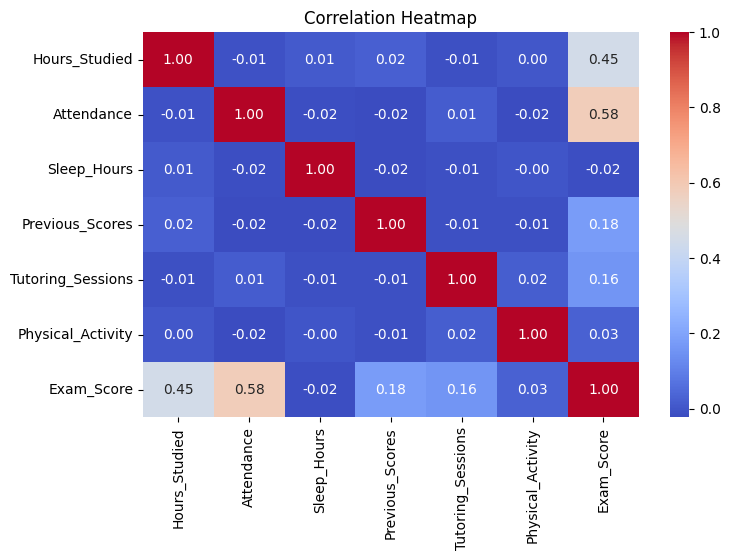

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


numeric_df = df.select_dtypes(include=[np.number])


corr_matrix = np.corrcoef(numeric_df.T)


plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            xticklabels=numeric_df.columns,
            yticklabels=numeric_df.columns,
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

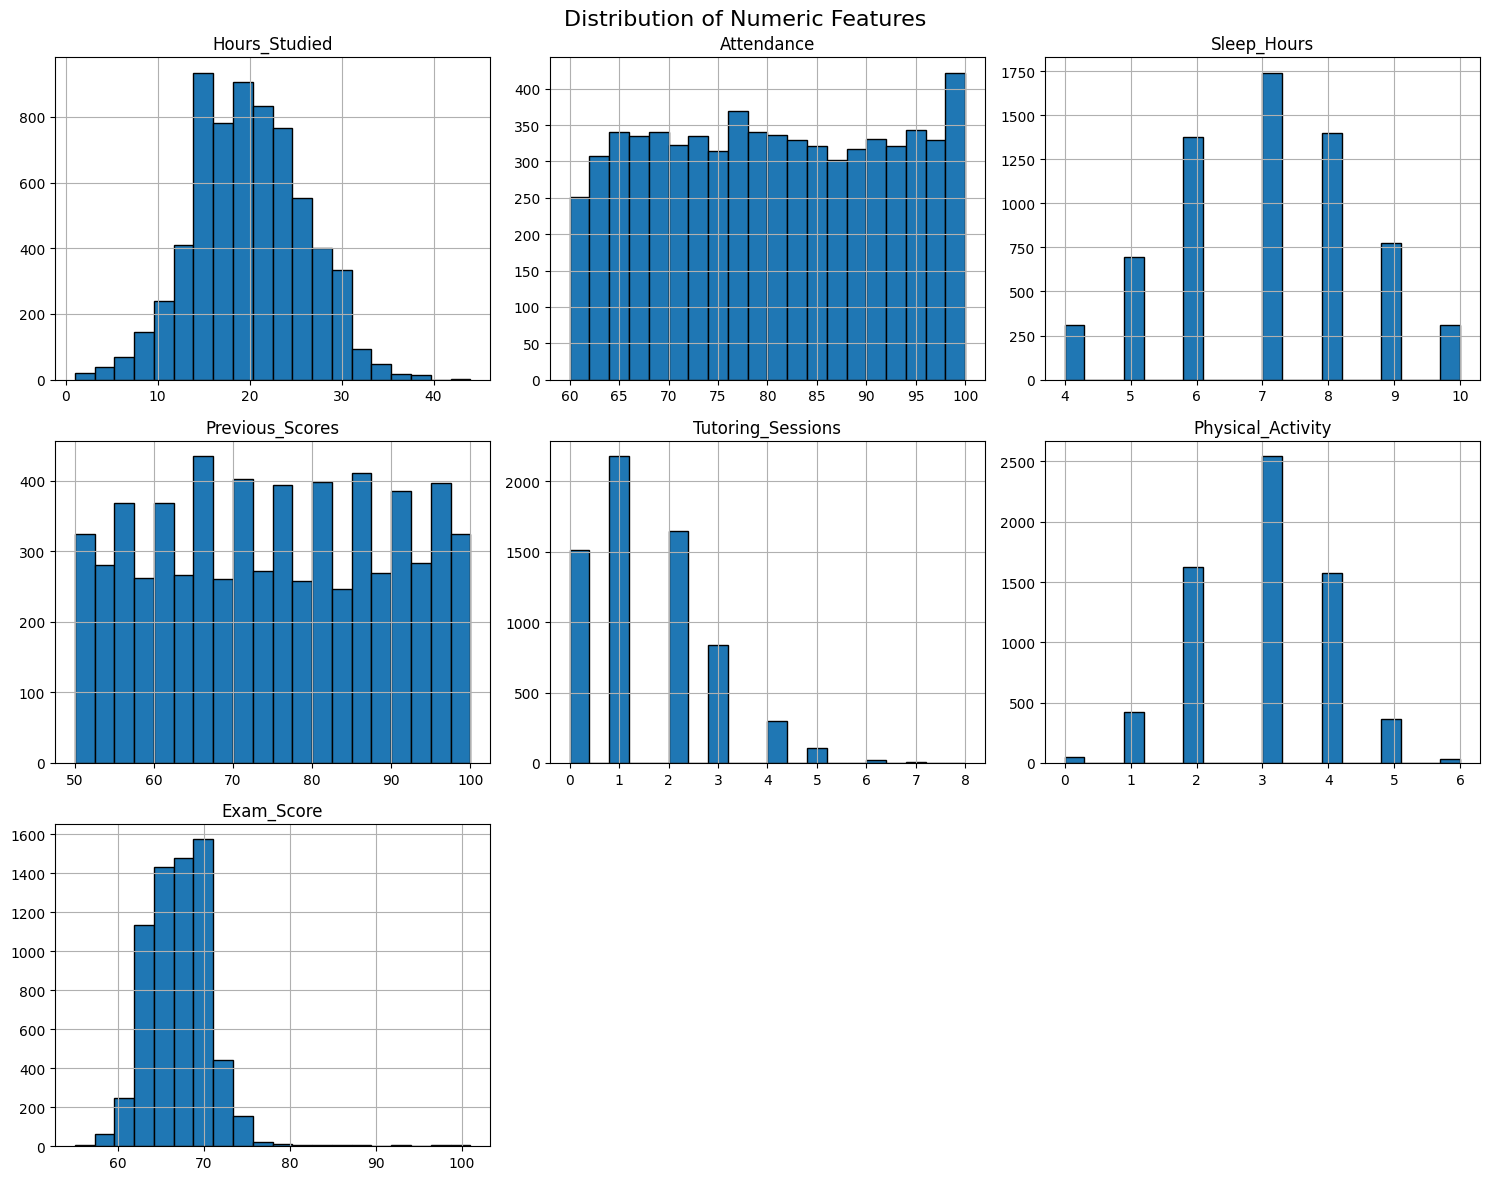

In [ ]:
df[numeric_cols].hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

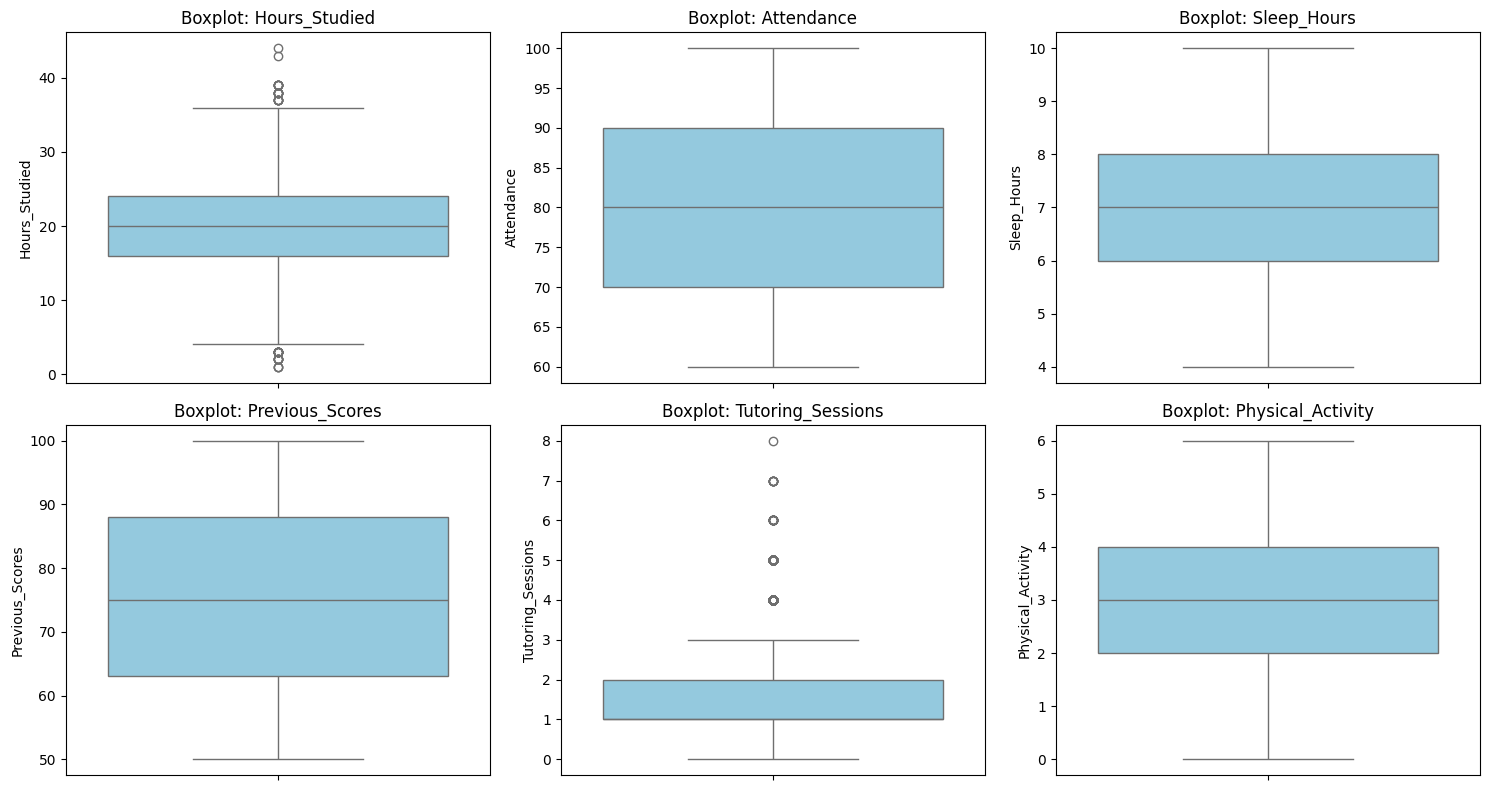

In [ ]:
target = 'Exam_Score'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_cols if c != target]

fig, axes = plt.subplots(nrows=(len(numeric_features)+2)//3, ncols=3, figsize=(15, 4*((len(numeric_features)+2)//3)))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1282/3207880166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1282/3207880166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1282/3207880166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1282/3207880166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

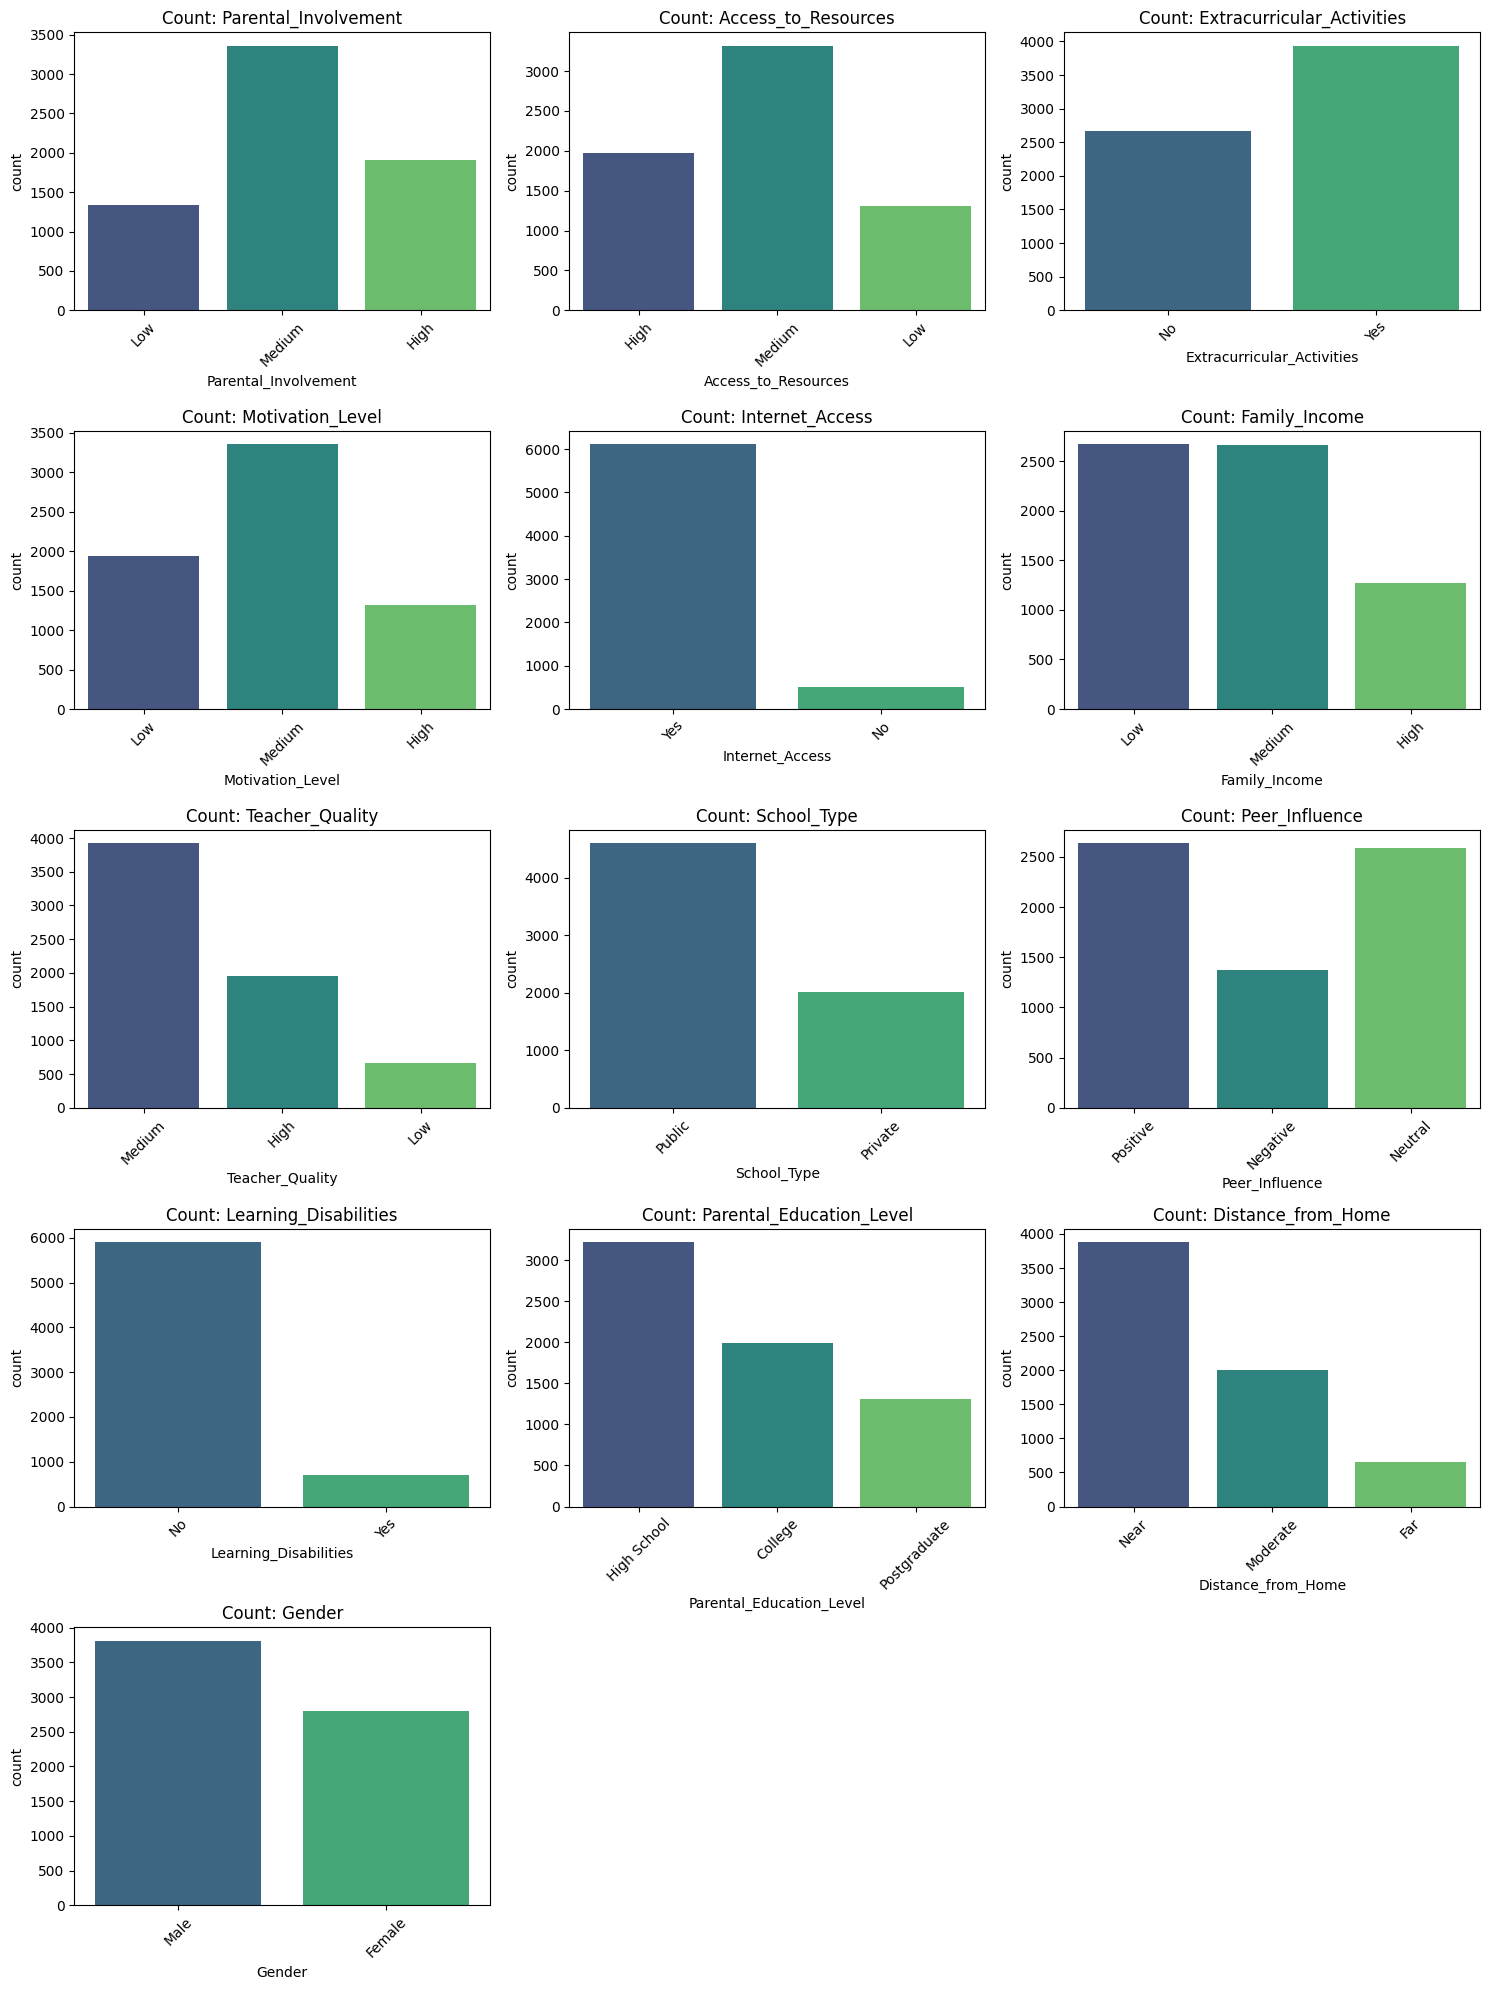

In [ ]:
fig, axes = plt.subplots(nrows=(len(object_cols)+2)//3, ncols=3, figsize=(15, 4*((len(object_cols)+2)//3)))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Count: {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


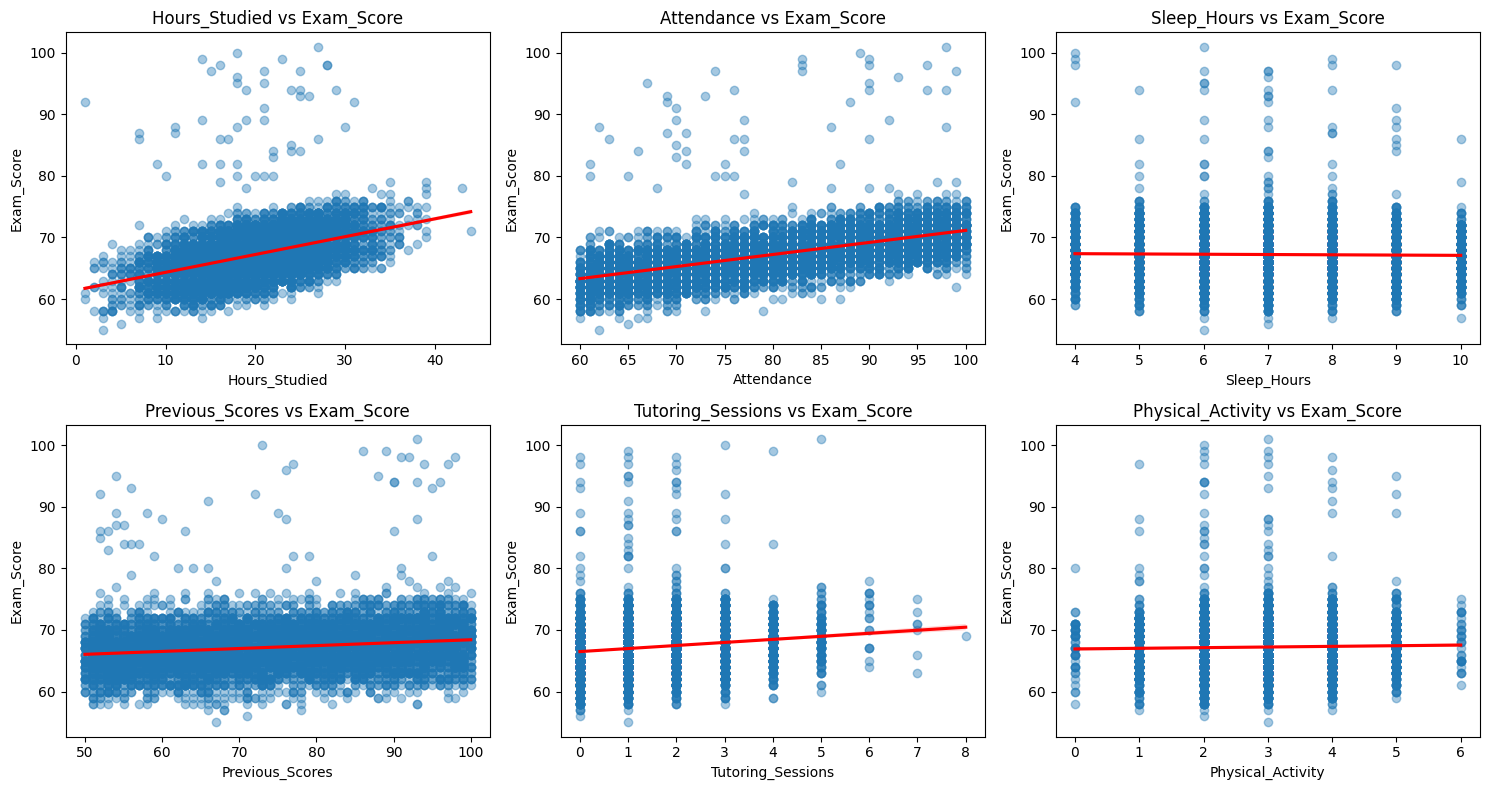

In [ ]:
fig, axes = plt.subplots(nrows=(len(numeric_features)+2)//3, ncols=3, figsize=(15, 4*((len(numeric_features)+2)//3)))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.regplot(data=df, x=col, y=target, ax=axes[i],
                scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs {target}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1265/2149192288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=axes[i], palette='Set2')
/tmp/ipykernel_1265/2149192288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=axes[i], palette='Set2')
/tmp/ipykernel_1265/2149192288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, ax=axes[i], palette='Set2')
/tmp/ipykernel_1265/2149192288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

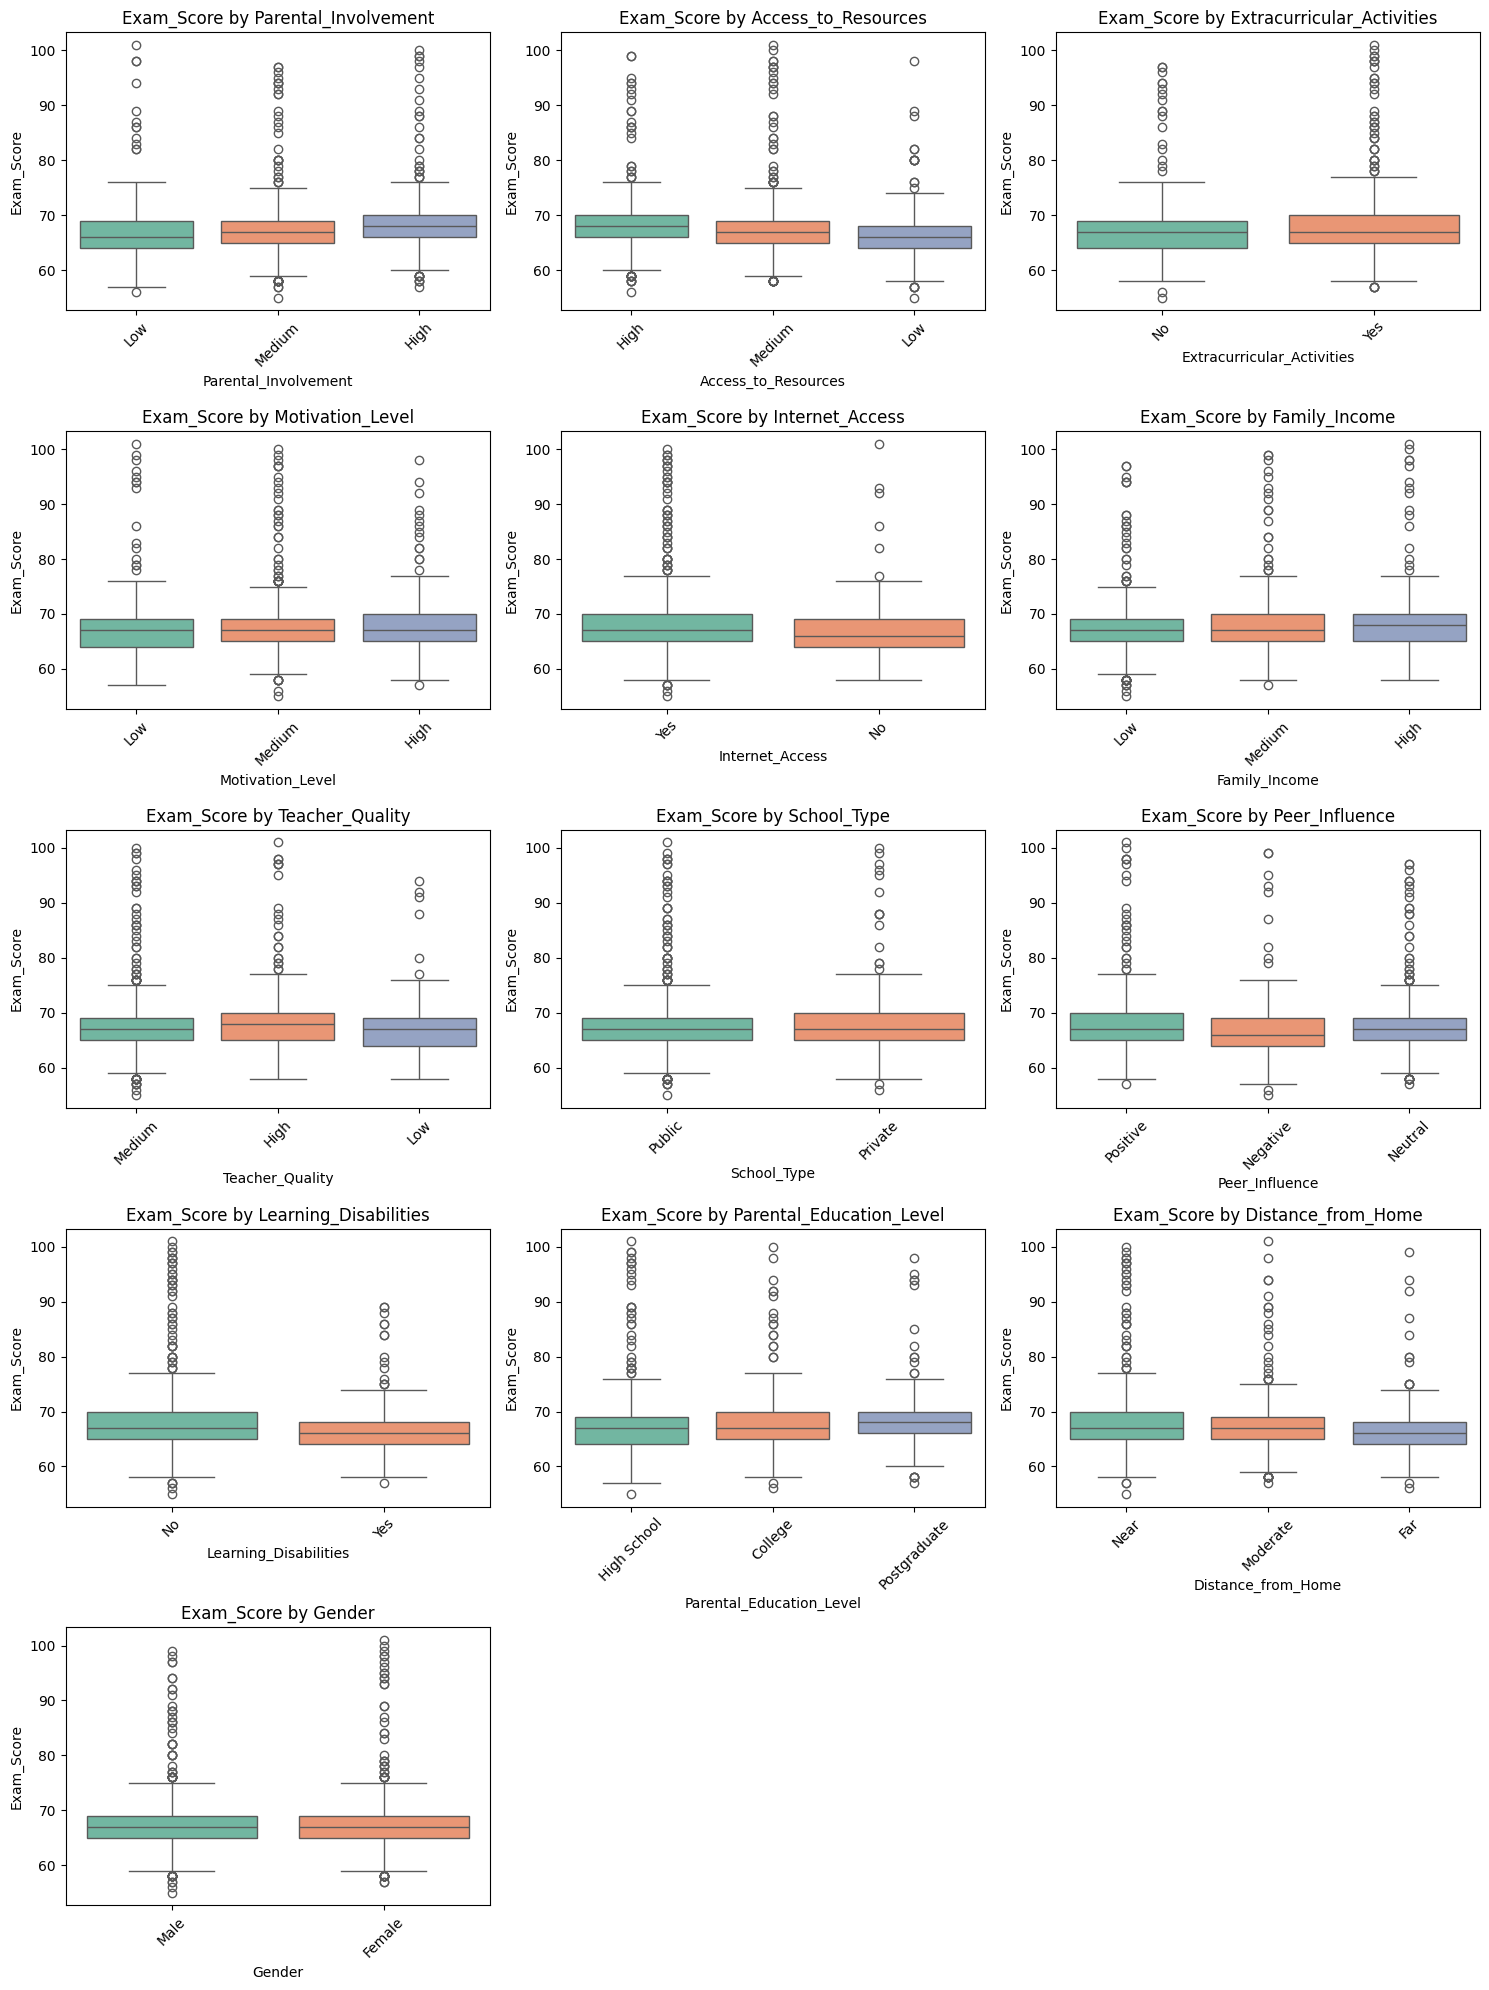

In [ ]:
fig, axes = plt.subplots(nrows=(len(object_cols)+2)//3, ncols=3, figsize=(15, 4*((len(object_cols)+2)//3)))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.boxplot(data=df, x=col, y=target, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{target} by {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
df_fe = df.copy()


df_fe['Study_Efficiency'] = df_fe['Hours_Studied'] / df_fe['Sleep_Hours'].replace(0, np.nan)
df_fe['Study_Efficiency'] = df_fe['Study_Efficiency'].fillna(df_fe['Study_Efficiency'].median())


df_fe['Attendance_Study_Ratio'] = df_fe['Attendance'] / df_fe['Hours_Studied'].replace(0, np.nan)
df_fe['Attendance_Study_Ratio'] = df_fe['Attendance_Study_Ratio'].fillna(df_fe['Attendance_Study_Ratio'].median())


df_fe['Effort_Score'] = (
    df_fe['Hours_Studied'] * 0.4 +
    df_fe['Attendance'] * 0.4 +
    df_fe['Tutoring_Sessions'] * 0.2
)

print("New derived columns:", ['Study_Efficiency', 'Attendance_Study_Ratio', 'Effort_Score'])
df_fe[['Hours_Studied', 'Sleep_Hours', 'Study_Efficiency',
       'Attendance', 'Attendance_Study_Ratio', 'Effort_Score']].head()


New derived columns: ['Study_Efficiency', 'Attendance_Study_Ratio', 'Effort_Score']


,Hours_Studied,Sleep_Hours,Study_Efficiency,Attendance,Attendance_Study_Ratio,Effort_Score
0,23,7,3.285714,84,3.652174,42.8
1,19,8,2.375000,64,3.368421,33.6
2,24,7,3.428571,98,4.083333,49.2
3,29,8,3.625000,89,3.068966,47.4
4,19,6,3.166667,92,4.842105,45.0


In [ ]:
for c in df_fe.columns:
    if df_fe[c].isnull().sum() > 0:
        if df_fe[c].dtype in [np.float64, np.int64]:
            df_fe[c].fillna(df_fe[c].median(), inplace=True)
        else:
            df_fe[c].fillna(df_fe[c].mode()[0], inplace=True)

print("Remaining nulls:", df_fe.isnull().sum().sum())

Remaining nulls: 0


/tmp/ipykernel_1265/1556996371.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe[c].fillna(df_fe[c].mode()[0], inplace=True)


In [ ]:
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}

for c in object_cols:
    uniques = set(df_fe[c].dropna().unique())
    if uniques.issubset(set(ordinal_map.keys())):
        df_fe[c] = df_fe[c].map(ordinal_map)
    else:
        df_fe = pd.get_dummies(df_fe, columns=[c], drop_first=True)

print("Shape after full encoding:", df_fe.shape)
df_fe.head()

Shape after full encoding: (6607, 26)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Internet_Access_Yes,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,...,True,True,False,True,False,True,False,False,True,True
1,19,64,0,1,8,59,0,2,1,1,...,True,True,False,False,False,False,False,True,False,False
2,24,98,1,1,7,91,1,2,1,1,...,True,True,True,False,False,False,True,False,True,True
3,29,89,0,1,8,98,1,1,1,1,...,True,True,False,False,False,True,False,True,False,True
4,19,92,1,1,6,65,1,3,1,2,...,True,True,True,False,False,False,False,False,True,False


In [ ]:
from sklearn.preprocessing import StandardScaler
feature_cols = [c for c in df_fe.columns if c != target]
cols_to_scale = df_fe[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cols_to_scale = [c for c in cols_to_scale if df_fe[c].nunique() > 2]

scaler = StandardScaler()
df_fe[cols_to_scale] = scaler.fit_transform(df_fe[cols_to_scale])

print("Scaled columns:", cols_to_scale)
df_fe.head()
print("Final feature-engineered shape:", df_fe.shape)
print("\nColumns:\n", df_fe.columns.tolist())

Scaled columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Physical_Activity', 'Study_Efficiency', 'Attendance_Study_Ratio', 'Effort_Score']
Final feature-engineered shape: (6607, 26)

Columns:
 ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Physical_Activity', 'Exam_Score', 'Study_Efficiency', 'Attendance_Study_Ratio', 'Effort_Score', 'Extracurricular_Activities_Yes', 'Internet_Access_Yes', 'School_Type_Public', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near', 'Gender_Male']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


target = 'Exam_Score'
X = df_fe.drop(columns=[target])
y = df_fe[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5285, 25)
Test shape: (1322, 25)


In [ ]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline Linear Regression RMSE: {rmse:.4f}")
print(f"Baseline Linear Regression R²: {r2:.4f}")

Baseline Linear Regression RMSE: 1.8101
Baseline Linear Regression R²: 0.7682


In [ ]:
!pip install -q xgboost lightgbm

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [ ]:
results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)


    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2,CV_R2_mean,CV_R2_std
0,Ridge Regression,1.810094,0.456947,0.768205,0.711905,0.035407
1,Linear Regression,1.810107,0.456925,0.768201,0.711899,0.035425
2,Lasso Regression,1.895125,0.715420,0.745916,0.685217,0.031281
3,Gradient Boosting,1.906482,0.660145,0.742861,0.678622,0.033653
4,LightGBM,1.990182,0.815904,0.719788,0.672931,0.031938
5,XGBoost,2.130915,0.957792,0.678757,0.623688,0.034179
6,Random Forest,2.163204,1.025567,0.668948,0.624039,0.039277


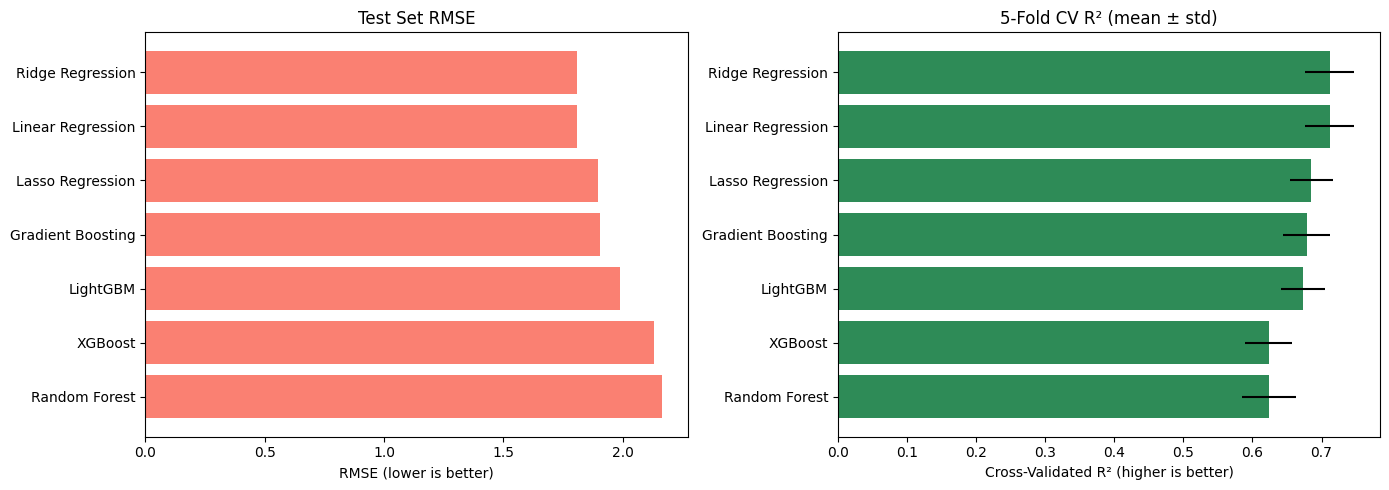

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Model'], results_df['RMSE'], color='salmon')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Test Set RMSE')
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['CV_R2_mean'], xerr=results_df['CV_R2_std'], color='seagreen')
axes[1].set_xlabel('Cross-Validated R² (higher is better)')
axes[1].set_title('5-Fold CV R² (mean ± std)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

best_model_name = results_df.iloc[0]['Model']
print("Best baseline model:", best_model_name)

Best baseline model: Ridge Regression


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Best CV RMSE: 2.1767879247665407


In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
Best CV RMSE: 2.3092952132262803


/tmp/ipykernel_1282/29337234.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')


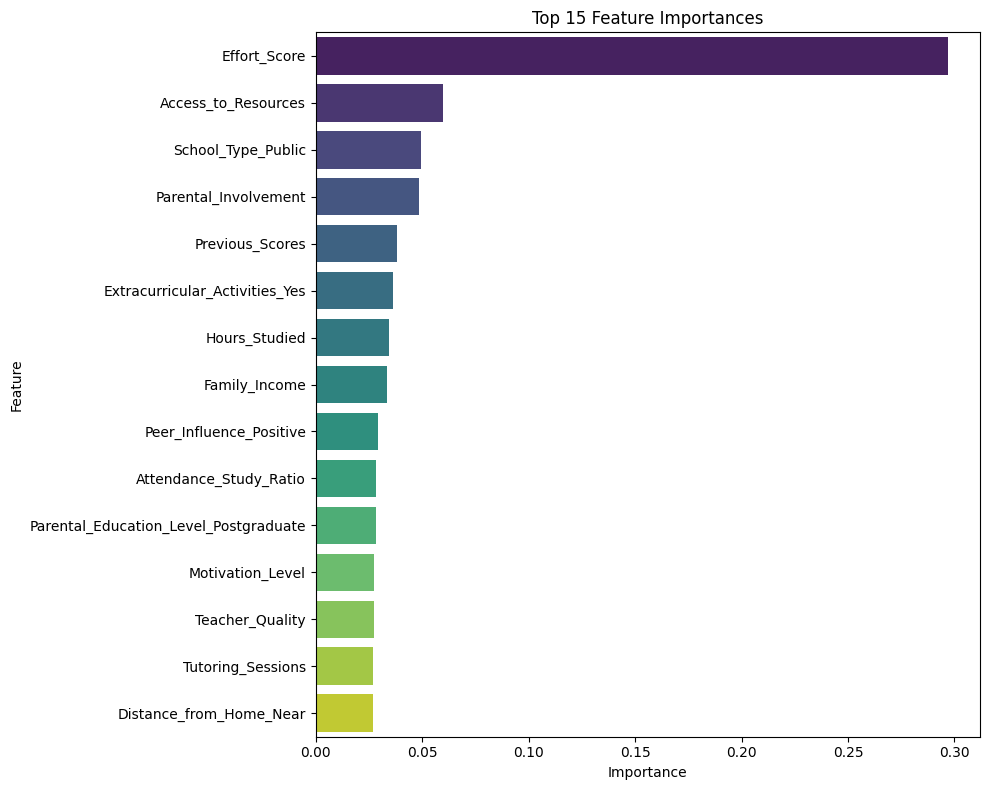

,Feature,Importance
13,Effort_Score,0.297162
3,Access_to_Resources,0.059969
16,School_Type_Public,0.049574
2,Parental_Involvement,0.048659
5,Previous_Scores,0.038074
14,Extracurricular_Activities_Yes,0.036274
0,Hours_Studied,0.034344
8,Family_Income,0.033328
18,Peer_Influence_Positive,0.029016
12,Attendance_Study_Ratio,0.028168


In [ ]:
best_model = xgb_search.best_estimator_

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

importances.head(15)

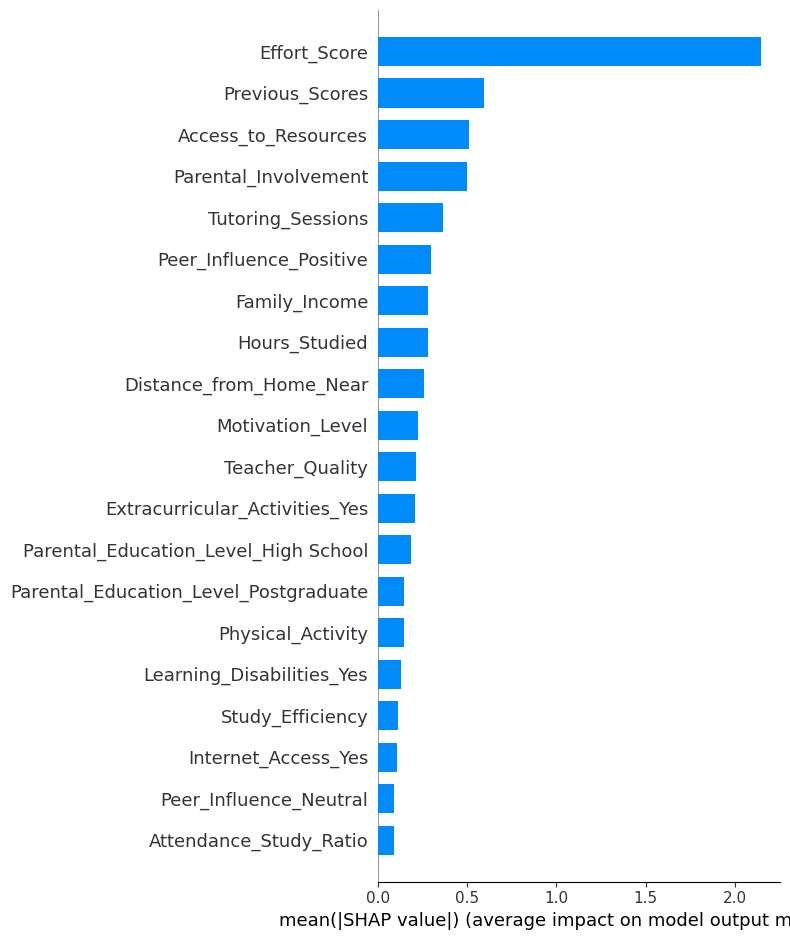

In [ ]:
!pip install -q shap
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')

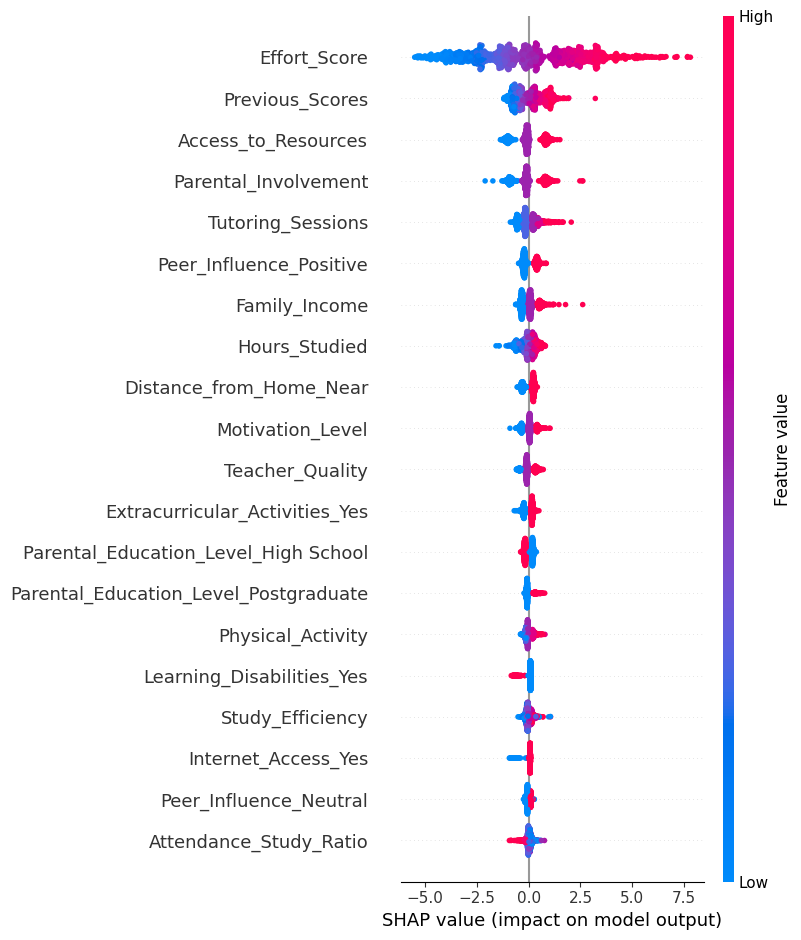

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
final_model = best_model

y_pred_final = final_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae = mean_absolute_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print("===== FINAL MODEL PERFORMANCE (held-out test set) =====")
print(f"Model: {type(final_model).__name__}")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")
print(f"R²: {final_r2:.4f}")

===== FINAL MODEL PERFORMANCE (held-out test set) =====
Model: XGBRegressor
RMSE: 1.9443
MAE: 0.7113
R²: 0.7325


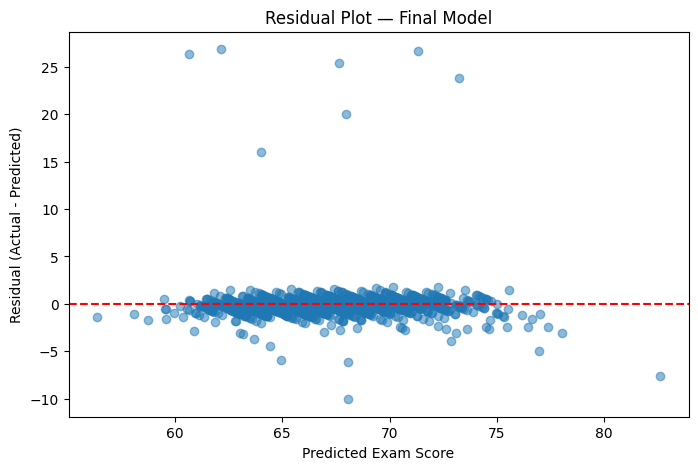

In [ ]:
residuals = y_test - y_pred_final

plt.figure(figsize=(8,5))
plt.scatter(y_pred_final, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Final Model')
plt.show()

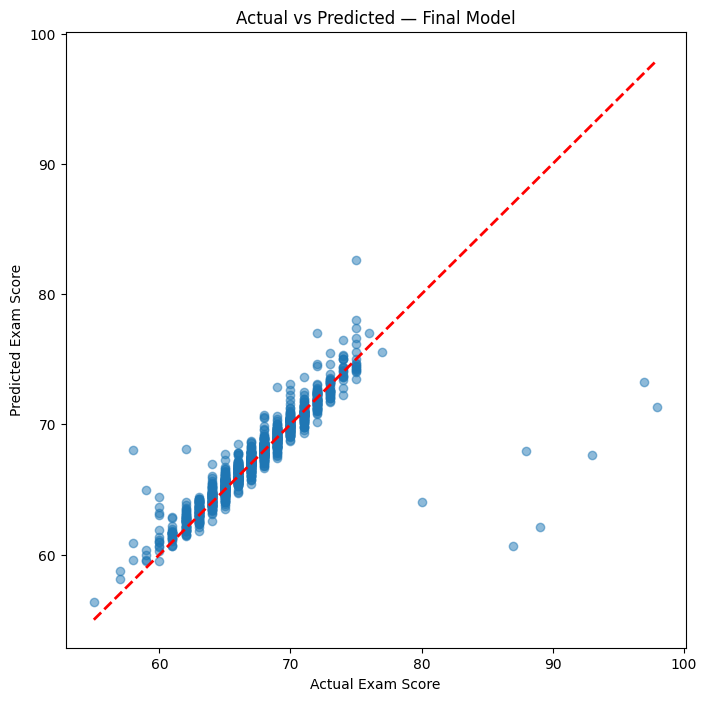

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted — Final Model')
plt.show()

In [ ]:
import joblib
joblib.dump(final_model, 'final_student_performance_model.pkl')
print("Model saved.")

Model saved.
